# AI Driven Export Market Decision Support System

## QM 640 Capstone Project

### Student
Pavithra Bharathi

### Walsh University

---

## Project Objective

This project aims to develop an AI-driven export market decision support system to identify high-potential international markets for Indian exports. The study integrates TradeStat, UN Comtrade, and World Bank datasets to analyze historical trade performance, evaluate macroeconomic indicators, and generate data-driven recommendations for exporters.

---

## Research Questions

RQ1.
Which export commodities and international markets exhibit the highest growth potential for India?

RQ2.
Which macroeconomic indicators significantly influence India's export performance?

RQ3.
How does international competition affect India's export opportunities across selected commodities?

RQ4.
Can machine learning models accurately identify attractive export markets?

---

## Data Sources

1. TradeStat (Government of India)

2. UN Comtrade

3. World Bank World Development Indicators

---

## Expected Outputs

• Clean integrated dataset

• Exploratory Data Analysis

• Statistical Analysis

• Machine Learning Models

• Export Market Recommendation Framework

Environment Setup

In [3]:
# =====================================
# INSTALL REQUIRED PACKAGES
# =====================================

!pip install openpyxl
!pip install xlrd
!pip install seaborn
!pip install statsmodels
!pip install xgboost
!pip install missingno

Clone Repository

In [1]:
# =====================================
# CLONE GITHUB REPOSITORY
# =====================================

!git clone https://github.com/bharathipavithra10-cmd/AI-Export-Market-Decision-Support.git

Cloning into 'AI-Export-Market-Decision-Support'...
remote: Enumerating objects: 220, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (201/201), done.
remote: Total 220 (delta 80), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (220/220), 15.07 MiB | 11.84 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [2]:
# =====================================
# IMPORT LIBRARIES
# =====================================

import os
import re
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

Project Directory

In [80]:
PROJECT_ROOT = Path("/content/AI-Export-Market-Decision-Support")

RAW_DATA = PROJECT_ROOT/"data"/"raw"

TRADESTAT_DIR = RAW_DATA/"tradestate"

UNCOMTRADE_DIR = RAW_DATA/"un_comtrade"

WORLD_BANK_DIR = RAW_DATA/"WORLD_BANK"

OUTPUT_DIR = PROJECT_ROOT/"outputs"

FIGURES_DIR = OUTPUT_DIR/"figures"

TABLES_DIR = OUTPUT_DIR/"tables"

CLEAN_DIR = PROJECT_ROOT/"data"/"cleaned"

PROCESSED_DIR = PROJECT_ROOT/"data"/"processed"

Create Output Folders

In [4]:
for folder in [

    OUTPUT_DIR,

    FIGURES_DIR,

    TABLES_DIR,

    CLEAN_DIR,

    PROCESSED_DIR

]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Folders Created Successfully")

Folders Created Successfully


Verify Dataset

In [5]:
print("="*50)
print("TRADESTAT FILES")
print("="*50)

trade_files = sorted(
    TRADESTAT_DIR.rglob("*.xlsx")
)

print(len(trade_files))

for f in trade_files:

    print(f.name)

TRADESTAT FILES
29
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2023.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2023_2024.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2024_2025.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2025-2026.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2023.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2023_2024.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2024_2025.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2025_2026.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2020_2021.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2021_2022.xlsx
TradeStat-Eidb-Export-Commodity-wise-all-countries_2022_2

Verify UN Comtrade

In [6]:
print("="*50)
print("UN COMTRADE")
print("="*50)

comtrade_files = sorted(
    UNCOMTRADE_DIR.glob("*.xlsx")
)

for f in comtrade_files:

    print(f.name)

UN COMTRADE
TradeData_7_21_2026_1_4_20.xlsx


Verify World Bank

In [7]:
print("="*50)
print("WORLD BANK")
print("="*50)

wb_files = sorted(
    WORLD_BANK_DIR.glob("*.xlsx")
)

for f in wb_files:

    print(f.name)

WORLD BANK
P_Data_Extract_From_World_Development_Indicators.xlsx


Dataset Summary

In [8]:
summary = pd.DataFrame({

    "Dataset":[

        "TradeStat",

        "UN Comtrade",

        "World Bank"

    ],

    "Files":[

        len(trade_files),

        len(comtrade_files),

        len(wb_files)

    ]

})

summary

,Dataset,Files
0,TradeStat,29
1,UN Comtrade,1
2,World Bank,1


Data Quality Assessment

In [9]:
print("="*60)

print("PROJECT SUMMARY")

print("="*60)

print(f"TradeStat Files : {len(trade_files)}")

print(f"UN Comtrade Files : {len(comtrade_files)}")

print(f"World Bank Files : {len(wb_files)}")

PROJECT SUMMARY
TradeStat Files : 29
UN Comtrade Files : 1
World Bank Files : 1


Notebook Progress

In [10]:
progress = pd.DataFrame({

    "Task":[

        "Repository",

        "Data Loading",

        "Data Cleaning",

        "Data Integration",

        "Feature Engineering",

        "EDA",

        "Regression",

        "Machine Learning"

    ],

    "Status":[

        "Completed",

        "Completed",

        "In Progress",

        "Pending",

        "Pending",

        "Pending",

        "Pending",

        "Pending"

    ]

})

progress

,Task,Status
0,Repository,Completed
1,Data Loading,Completed
2,Data Cleaning,In Progress
3,Data Integration,Pending
4,Feature Engineering,Pending
5,EDA,Pending
6,Regression,Pending
7,Machine Learning,Pending


PART 2 – Data Cleaning & Integration

In [11]:
# ==========================================
# LOAD ALL TRADESTAT FILES
# ==========================================

trade_files = sorted(TRADESTAT_DIR.rglob("*.xlsx"))

print(f"Total files found : {len(trade_files)}")

Total files found : 29


TradeStat Loader

In [12]:
def load_tradestat(file_path):

    df = pd.read_excel(
        file_path,
        skiprows=2
    )

    df.columns = [
        "Serial_No",
        "Country",
        "Export_Previous",
        "Export_Current",
        "Export_Growth",
        "Quantity_Previous",
        "Quantity_Current",
        "Quantity_Growth"
    ]

    df = df.dropna(how="all")

    df = df[
        ~df["Country"]
        .astype(str)
        .str.contains("Total",case=False)
    ]

    commodity = file_path.parent.name.replace(
        "commodity_",""
    )

    year = re.findall(
        r"(20\d{2})[_-](20\d{2})",
        file_path.name
    )[0][1]

    df["Commodity"]=commodity
    df["Year"]=int(year)

    return df

Read Everything

In [13]:
trade_frames=[]

for file in trade_files:

    try:

        trade_frames.append(
            load_tradestat(file)
        )

    except Exception as e:

        print(file)

        print(e)

Combine

In [14]:
from pathlib import Path

PROJECT_ROOT = Path("/content/AI-Export-Market-Decision-Support")

print(PROJECT_ROOT.exists())

True


In [15]:

import os

for root, dirs, files in os.walk("/content/AI-Export-Market-Decision-Support"):
    print(root)

/content/AI-Export-Market-Decision-Support
/content/AI-Export-Market-Decision-Support/docs
/content/AI-Export-Market-Decision-Support/.git
/content/AI-Export-Market-Decision-Support/.git/branches
/content/AI-Export-Market-Decision-Support/.git/info
/content/AI-Export-Market-Decision-Support/.git/objects
/content/AI-Export-Market-Decision-Support/.git/objects/info
/content/AI-Export-Market-Decision-Support/.git/objects/pack
/content/AI-Export-Market-Decision-Support/.git/refs
/content/AI-Export-Market-Decision-Support/.git/refs/remotes
/content/AI-Export-Market-Decision-Support/.git/refs/remotes/origin
/content/AI-Export-Market-Decision-Support/.git/refs/heads
/content/AI-Export-Market-Decision-Support/.git/refs/tags
/content/AI-Export-Market-Decision-Support/.git/logs
/content/AI-Export-Market-Decision-Support/.git/logs/refs
/content/AI-Export-Market-Decision-Support/.git/logs/refs/remotes
/content/AI-Export-Market-Decision-Support/.git/logs/refs/remotes/origin
/content/AI-Export-Marke

In [16]:
import os

print(os.listdir("/content/AI-Export-Market-Decision-Support/data/raw"))

['rreadme.md', 'un_comtrade', 'WORLD_BANK', 'tradestate', 'readme.md']


In [17]:
tradestat=pd.concat(
    trade_frames,
    ignore_index=True
)

print(tradestat.shape)

tradestat.head()

(6040, 10)


,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year
0,1,AFGHANISTAN,0.31,0.84,167.87,NaN,NaN,NaN,27,2021
1,2,ALBANIA,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021
2,3,ALGERIA,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021
3,4,ANGOLA,0.24,0.87,270.22,NaN,NaN,NaN,27,2021
4,5,ARGENTINA,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021


Numeric Conversion

In [18]:
numeric_columns=[

"Export_Previous",

"Export_Current",

"Export_Growth",

"Quantity_Previous",

"Quantity_Current",

"Quantity_Growth"

]

for col in numeric_columns:

    tradestat[col]=(

        tradestat[col]

        .astype(str)

        .str.replace(",","")

        .str.strip()

    )

    tradestat[col]=pd.to_numeric(

        tradestat[col],

        errors="coerce"

    )

Missing Values

In [19]:
missing=tradestat.isnull().sum()

missing=missing.reset_index()

missing.columns=[

"Variable",

"Missing Values"

]

missing

,Variable,Missing Values
0,Serial_No,0
1,Country,0
2,Export_Previous,239
3,Export_Current,234
4,Export_Growth,473
5,Quantity_Previous,6040
6,Quantity_Current,6040
7,Quantity_Growth,6040
8,Commodity,0
9,Year,0


Duplicate Rows

In [20]:
duplicates=tradestat.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


Save Clean TradeStat

In [21]:
tradestat.to_csv(

    CLEAN_DIR/"tradestat_clean.csv",

    index=False

)

Load UN Comtrade

In [22]:
# ==========================================
# LOAD UN COMTRADE (XLSX)
# ==========================================

comtrade_file = list(UNCOMTRADE_DIR.glob("*.xlsx"))[0]

print("Loading:", comtrade_file.name)

comtrade = pd.read_excel(
    comtrade_file,
    engine="openpyxl"
)

print(comtrade.shape)

comtrade.head()

Loading: TradeData_7_21_2026_1_4_20.xlsx
(100000, 47)


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,1146.40,640.00,1146.40,0,False,True
1,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,572806.98,555763.48,572806.98,0,False,True
2,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,63.00,20.00,63.00,0,False,True
3,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,886.95,850.01,886.95,0,False,True
4,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,False,0,False,66.03,50.00,66.03,0,False,True


Keep Required Columns

In [23]:
required=[

"refYear",

"partnerDesc",

"partnerISO",

"cmdCode",

"cmdDesc",

"flowDesc",

"primaryValue",

"qty",

"netWgt",

"reporterDesc"

]

comtrade=comtrade[required]

comtrade.head()

,refYear,partnerDesc,partnerISO,cmdCode,cmdDesc,flowDesc,primaryValue,qty,netWgt,reporterDesc
0,2020,Venezuela,VEN,84,"Nuclear reactors, boilers, machinery and mecha...",Import,1146.40,0,0.0,Angola
1,2020,Zambia,ZMB,84,"Nuclear reactors, boilers, machinery and mecha...",Import,572806.98,0,0.0,Angola
2,2020,Saudi Arabia,SAU,71,"Natural, cultured pearls; precious, semi-preci...",Import,63.00,0,0.0,Angola
3,2020,Singapore,SGP,71,"Natural, cultured pearls; precious, semi-preci...",Import,886.95,0,0.0,Angola
4,2020,Mozambique,MOZ,71,"Natural, cultured pearls; precious, semi-preci...",Import,66.03,0,0.0,Angola


Rename Columns

In [24]:
comtrade.columns=[

"Year",

"Country",

"Country_ISO",

"Commodity",

"Commodity_Name",

"Trade_Flow",

"Trade_Value",

"Quantity",

"Net_Weight",

"Reporter"

]

Keep Only India's Imports

In [25]:
comtrade=comtrade[

    (comtrade["Reporter"]=="India")

]

comtrade.head()

,Year,Country,Country_ISO,Commodity,Commodity_Name,Trade_Flow,Trade_Value,Quantity,Net_Weight,Reporter


Convert Numerics

In [26]:
for col in [

"Trade_Value",

"Quantity",

"Net_Weight"

]:

    comtrade[col]=pd.to_numeric(

        comtrade[col],

        errors="coerce"

    )

Save

In [27]:
comtrade.to_csv(

    CLEAN_DIR/"uncomtrade_clean.csv",

    index=False

)

Load World Bank

In [28]:
wb_file=list(

WORLD_BANK_DIR.glob("*.xlsx")

)[0]

worldbank=pd.read_excel(

wb_file,

sheet_name=0

)

worldbank.head()

,Country Name,Country Code,Series Name,Series Code,2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,19955929052.149597,14259995441.075907,14497243872.133739,17152234636.871508,17778508875.739643,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,-2.351101,-20.738839,-6.240172,2.266944,1.873193,..
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,510.787063,356.496214,357.261153,413.757895,416.871146,..
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,39068979,40000412,40578842,41454761,42647492,43844111
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.601888,5.133203,13.712102,-4.644709,-6.601186,..


Keep Indicators

In [29]:
worldbank.columns

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code',
       '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]',
       '2024 [YR2024]', '2025 [YR2025]'],
      dtype='object')

World Bank Cleaning, Data Integration & Feature Engineering

In [30]:
# ==========================================
# WORLD BANK OVERVIEW
# ==========================================

print("Shape:", worldbank.shape)

display(worldbank.head())

print("\nColumns:")
print(worldbank.columns.tolist())

Shape: (2125, 10)


,Country Name,Country Code,Series Name,Series Code,2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,19955929052.149597,14259995441.075907,14497243872.133739,17152234636.871508,17778508875.739643,..
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,-2.351101,-20.738839,-6.240172,2.266944,1.873193,..
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,510.787063,356.496214,357.261153,413.757895,416.871146,..
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,39068979,40000412,40578842,41454761,42647492,43844111
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.601888,5.133203,13.712102,-4.644709,-6.601186,..



Columns:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']


In [31]:
# ==========================================
# REMOVE EMPTY ROWS/COLUMNS
# ==========================================

worldbank = worldbank.dropna(how="all")
worldbank = worldbank.dropna(axis=1, how="all")

print(worldbank.shape)

(2122, 10)


In [32]:
# ==========================================
# CLEAN YEAR COLUMN NAMES
# ==========================================

worldbank.columns = (
    worldbank.columns
    .str.replace(r"\s*\[YR\d+\]", "", regex=True)
)

print(worldbank.columns)

Index(['Country Name', 'Country Code', 'Series Name', 'Series Code', '2020',
       '2021', '2022', '2023', '2024', '2025'],
      dtype='object')


In [33]:
# ==========================================
# CONVERT YEARS TO ROWS
# ==========================================

year_columns = ["2020","2021","2022","2023","2024","2025"]

worldbank_long = pd.melt(
    worldbank,
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

worldbank_long["Year"] = worldbank_long["Year"].astype(int)

print(worldbank_long.shape)
display(worldbank_long.head(10))

(12732, 6)


,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,2020,19955929052.149597
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.351101
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2020,510.787063
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2020,39068979
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2020,5.601888
5,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,2020,46.709895
6,Afghanistan,AFG,Imports of goods and services (% of GDP),NE.IMP.GNFS.ZS,2020,36.289077
7,Afghanistan,AFG,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,2020,10.420817
8,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2020,938546103425.609009
9,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.930764


In [34]:
year_columns = ["2020", "2021", "2022", "2023", "2024", "2025"]

worldbank_long = pd.melt(
    worldbank,
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    value_vars=year_columns,
    var_name="Year",
    value_name="Value"
)

worldbank_long["Year"] = worldbank_long["Year"].astype(int)

display(worldbank_long.head(10))

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,2020,19955929052.149597
1,Afghanistan,AFG,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.351101
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2020,510.787063
3,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2020,39068979
4,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2020,5.601888
5,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,2020,46.709895
6,Afghanistan,AFG,Imports of goods and services (% of GDP),NE.IMP.GNFS.ZS,2020,36.289077
7,Afghanistan,AFG,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,2020,10.420817
8,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2020,938546103425.609009
9,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2020,-2.930764


In [35]:
worldbank_clean = worldbank_long.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value",
    aggfunc="first"
).reset_index()

worldbank_clean.columns.name = None

display(worldbank_clean.head())

,Country Name,Year,Exports of goods and services (% of GDP),GDP (current US$),GDP growth (annual %),GDP per capita (current US$),Imports of goods and services (% of GDP),"Inflation, consumer prices (annual %)","Population, total",Trade (% of GDP)
0,Afghanistan,2020,10.420817,19955929052.149597,-2.351101,510.787063,36.289077,5.601888,39068979,46.709895
1,Afghanistan,2021,14.342153,14259995441.075907,-20.738839,356.496214,37.069564,5.133203,40000412,51.411716
2,Afghanistan,2022,18.380042,14497243872.133739,-6.240172,357.261153,54.505427,13.712102,40578842,72.88547
3,Afghanistan,2023,16.235278,17152234636.871508,2.266944,413.757895,50.7643,-4.644709,41454761,66.999578
4,Afghanistan,2024,15.702752,17778508875.739643,1.873193,416.871146,68.060273,-6.601186,42647492,83.763025


In [36]:
master = tradestat.merge(
    worldbank_clean,
    left_on=["Country", "Year"],
    right_on=["Country Name", "Year"],
    how="left"
)

In [37]:
worldbank_long = worldbank_long.dropna(subset=["Series Name"])

In [38]:
worldbank_clean = worldbank_clean.rename(columns={
    "Country Name": "Country",
    "GDP (current US$)": "GDP",
    "GDP growth (annual %)": "GDP_Growth",
    "GDP per capita (current US$)": "GDP_Per_Capita",
    "Population, total": "Population",
    "Inflation, consumer prices (annual %)": "Inflation",
    "Exports of goods and services (% of GDP)": "Exports_GDP",
    "Imports of goods and services (% of GDP)": "Imports_GDP",
    "Trade (% of GDP)": "Trade_GDP"
})

In [39]:
# ==========================================
# STANDARDIZE COUNTRY NAMES
# ==========================================

def clean_country(df, column):

    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.title()
    )

    return df

tradestat = clean_country(tradestat, "Country")
comtrade = clean_country(comtrade, "Country")
worldbank_clean = clean_country(worldbank_clean, "Country")

In [40]:
print("TradeStat :", tradestat.shape)

print("Comtrade :", comtrade.shape)

print("World Bank :", worldbank_clean.shape)

TradeStat : (6040, 10)
Comtrade : (0, 10)
World Bank : (1590, 10)


In [41]:
print(tradestat.columns.tolist())

['Serial_No', 'Country', 'Export_Previous', 'Export_Current', 'Export_Growth', 'Quantity_Previous', 'Quantity_Current', 'Quantity_Growth', 'Commodity', 'Year']


In [42]:
print(comtrade.columns.tolist())

['Year', 'Country', 'Country_ISO', 'Commodity', 'Commodity_Name', 'Trade_Flow', 'Trade_Value', 'Quantity', 'Net_Weight', 'Reporter']


In [43]:
tradestat.head()

,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021


In [44]:
# ==========================================
# MERGE TRADESTAT + WORLD BANK
# ==========================================

master = tradestat.merge(
    worldbank_clean,
    on=["Country", "Year"],
    how="left"
)

print(master.shape)
display(master.head())

(6040, 18)


,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year,Exports_GDP,GDP,GDP_Growth,GDP_Per_Capita,Imports_GDP,Inflation,Population,Trade_GDP
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021,14.342153,14259995441.075907,-20.738839,356.496214,37.069564,5.133203,40000412,51.411716
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021,31.133056,18031989573.029366,8.969576,7242.455131,44.457348,2.041472,2489762,75.590404
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021,23.444367,186231205262.082367,3.8,4160.559267,23.392692,7.226063,44761099,46.837059
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021,40.092305,78283923543.823669,1.090584,2266.968349,22.436465,25.754295,34532429,62.528771
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021,18.066709,486564085480.035522,10.441812,10738.017922,15.01198,48.409379,45312281,33.07869


In [45]:
# ==========================================
# AGGREGATE UN COMTRADE
# ==========================================

comtrade_summary = (
    comtrade
    .groupby(["Country", "Year"], as_index=False)
    .agg({
        "Trade_Value": "sum",
        "Quantity": "sum",
        "Net_Weight": "sum"
    })
)

display(comtrade_summary.head())

,Country,Year,Trade_Value,Quantity,Net_Weight


In [46]:
# ==========================================
# MERGE COMTRADE
# ==========================================

master = master.merge(
    comtrade_summary,
    on=["Country", "Year"],
    how="left"
)

print(master.shape)

(6040, 21)


In [47]:
master = master.rename(columns={
    "Trade_Value": "Import_Value",
    "Quantity": "Import_Quantity",
    "Net_Weight": "Import_Net_Weight"
})

In [48]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

master["Export_Value"] = master["Export_Current"]

master["Export_Growth_Rate"] = (
    (master["Export_Current"] - master["Export_Previous"])
    / master["Export_Previous"]
) * 100

master["Quantity_Growth_Rate"] = (
    (master["Quantity_Current"] - master["Quantity_Previous"])
    / master["Quantity_Previous"]
) * 100

In [49]:
# ==========================================
# MARKET SHARE
# ==========================================

year_totals = (
    master.groupby("Year")["Export_Value"]
    .transform("sum")
)

master["Market_Share"] = (
    master["Export_Value"] / year_totals
) * 100

In [50]:
# ==========================================
# Missing Values
# ==========================================
missing = (
    master.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing)

,0
Quantity_Current,6040
Quantity_Previous,6040
Quantity_Growth,6040
Import_Net_Weight,6040
Quantity_Growth_Rate,6040
Import_Value,6040
Import_Quantity,6040
GDP,2655
Exports_GDP,2655
Trade_GDP,2655


In [51]:
# ==========================================
# Save Master Dataset
# ==========================================
master.to_csv(
    PROCESSED_DIR / "master_dataset.csv",
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.


In [52]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Serial_No             6040 non-null   object 
 1   Country               6040 non-null   object 
 2   Export_Previous       5801 non-null   float64
 3   Export_Current        5806 non-null   float64
 4   Export_Growth         5567 non-null   float64
 5   Quantity_Previous     0 non-null      float64
 6   Quantity_Current      0 non-null      float64
 7   Quantity_Growth       0 non-null      float64
 8   Commodity             6040 non-null   object 
 9   Year                  6040 non-null   int64  
 10  Exports_GDP           3385 non-null   object 
 11  GDP                   3385 non-null   object 
 12  GDP_Growth            3385 non-null   object 
 13  GDP_Per_Capita        3385 non-null   object 
 14  Imports_GDP           3385 non-null   object 
 15  Inflation            

In [53]:
master.info()
master.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Serial_No             6040 non-null   object 
 1   Country               6040 non-null   object 
 2   Export_Previous       5801 non-null   float64
 3   Export_Current        5806 non-null   float64
 4   Export_Growth         5567 non-null   float64
 5   Quantity_Previous     0 non-null      float64
 6   Quantity_Current      0 non-null      float64
 7   Quantity_Growth       0 non-null      float64
 8   Commodity             6040 non-null   object 
 9   Year                  6040 non-null   int64  
 10  Exports_GDP           3385 non-null   object 
 11  GDP                   3385 non-null   object 
 12  GDP_Growth            3385 non-null   object 
 13  GDP_Per_Capita        3385 non-null   object 
 14  Imports_GDP           3385 non-null   object 
 15  Inflation            

,Serial_No,Country,Export_Previous,Export_Current,Export_Growth,Quantity_Previous,Quantity_Current,Quantity_Growth,Commodity,Year,...,Inflation,Population,Trade_GDP,Import_Value,Import_Quantity,Import_Net_Weight,Export_Value,Export_Growth_Rate,Quantity_Growth_Rate,Market_Share
0,1,Afghanistan,0.31,0.84,167.87,NaN,NaN,NaN,27,2021,...,5.133203,40000412,51.411716,NaN,NaN,NaN,0.84,170.967742,NaN,0.000795
1,2,Albania,0.02,0.00,-85.86,NaN,NaN,NaN,27,2021,...,2.041472,2489762,75.590404,NaN,NaN,NaN,0.00,-100.000000,NaN,0.000000
2,3,Algeria,3.19,2.08,-34.77,NaN,NaN,NaN,27,2021,...,7.226063,44761099,46.837059,NaN,NaN,NaN,2.08,-34.796238,NaN,0.001969
3,4,Angola,0.24,0.87,270.22,NaN,NaN,NaN,27,2021,...,25.754295,34532429,62.528771,NaN,NaN,NaN,0.87,262.500000,NaN,0.000824
4,5,Argentina,226.56,115.45,-49.04,NaN,NaN,NaN,27,2021,...,48.409379,45312281,33.07869,NaN,NaN,NaN,115.45,-49.042196,NaN,0.109304


In [54]:
# ==========================================
# CONVERT WORLD BANK VARIABLES TO NUMERIC
# ==========================================

wb_numeric = [
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]

for col in wb_numeric:
    master[col] = pd.to_numeric(master[col], errors="coerce")

master[wb_numeric].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GDP             3247 non-null   float64
 1   GDP_Growth      3248 non-null   float64
 2   GDP_Per_Capita  3247 non-null   float64
 3   Population      3385 non-null   float64
 4   Inflation       3024 non-null   float64
 5   Exports_GDP     2836 non-null   float64
 6   Imports_GDP     2836 non-null   float64
 7   Trade_GDP       2836 non-null   float64
dtypes: float64(8)
memory usage: 377.6 KB


In [55]:
##Remove unused quantity columns
master = master.drop(
    columns=[
        "Quantity_Previous",
        "Quantity_Current",
        "Quantity_Growth",
        "Quantity_Growth_Rate"
    ]
)

In [56]:
##Save the cleaned master dataset
master.to_csv(
    PROCESSED_DIR / "master_dataset.csv",
    index=False
)

print("Master dataset saved successfully.")

Master dataset saved successfully.


# Exploratory Data Analysis (EDA)

In [57]:
# ==========================================================
# 4.1 DATASET OVERVIEW
# ==========================================================
#
# Objective:
# Understand the size and structure of the integrated dataset.
#
# Outputs:
# • Number of observations
# • Number of variables
# • Data types
# • General information
# ==========================================================

print("="*70)
print("MASTER DATASET OVERVIEW")
print("="*70)

print(f"Rows    : {master.shape[0]}")
print(f"Columns : {master.shape[1]}")

master.info()

MASTER DATASET OVERVIEW
Rows    : 6040
Columns : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Serial_No           6040 non-null   object 
 1   Country             6040 non-null   object 
 2   Export_Previous     5801 non-null   float64
 3   Export_Current      5806 non-null   float64
 4   Export_Growth       5567 non-null   float64
 5   Commodity           6040 non-null   object 
 6   Year                6040 non-null   int64  
 7   Exports_GDP         2836 non-null   float64
 8   GDP                 3247 non-null   float64
 9   GDP_Growth          3248 non-null   float64
 10  GDP_Per_Capita      3247 non-null   float64
 11  Imports_GDP         2836 non-null   float64
 12  Inflation           3024 non-null   float64
 13  Population          3385 non-null   float64
 14  Trade_GDP           2836 non-null   float64
 15  Imp

In [58]:
# ==========================================================
# 4.2 MISSING VALUE ANALYSIS
# ==========================================================
#
# Objective:
# Identify incomplete variables and evaluate data quality.
#
# Missing values may occur because:
# • Trade was unavailable
# • World Bank indicators were unavailable
# • Quantity information is not reported for selected commodities
# ==========================================================

missing = master.isnull().sum().sort_values(ascending=False)

missing_percent = (
    master.isnull().mean()*100
).sort_values(ascending=False)

missing_df = pd.DataFrame({

    "Missing Values": missing,

    "Percentage (%)": missing_percent

})

display(missing_df)

,Missing Values,Percentage (%)
Import_Value,6040,100.000000
Import_Net_Weight,6040,100.000000
Import_Quantity,6040,100.000000
Exports_GDP,3204,53.046358
Trade_GDP,3204,53.046358
Imports_GDP,3204,53.046358
Inflation,3016,49.933775
GDP_Per_Capita,2793,46.241722
GDP,2793,46.241722
GDP_Growth,2792,46.225166


In [59]:
# ==========================================================
# 4.3 DESCRIPTIVE STATISTICS
# ==========================================================
#
# Objective:
# Summarize the numerical variables.
#
# Statistics include:
# • Mean
# • Standard deviation
# • Minimum
# • Maximum
# • Quartiles
# ==========================================================

master.describe()

,Export_Previous,Export_Current,Export_Growth,Year,Exports_GDP,GDP,GDP_Growth,GDP_Per_Capita,Imports_GDP,Inflation,Population,Trade_GDP,Import_Value,Import_Quantity,Import_Net_Weight,Export_Value,Export_Growth_Rate,Market_Share
count,5801.000000,5806.000000,5.567000e+03,6040.000000,2836.000000,3.247000e+03,3248.000000,3247.000000,2836.000000,3024.000000,3.385000e+03,2836.000000,0.0,0.0,0.0,5806.000000,5425.000000,5806.000000
mean,172.235859,184.433789,1.382473e+03,2023.427318,45.040809,3.185068e+11,4.098712,21640.778388,48.442474,9.451206,2.386913e+07,93.483283,NaN,NaN,NaN,184.433789,inf,0.103341
std,824.598107,899.897260,4.627522e+04,1.674452,32.606089,7.314107e+11,5.487266,33606.485565,27.142751,24.288813,4.165180e+07,57.840083,NaN,NaN,NaN,899.897260,NaN,0.500932
min,0.000000,0.000000,-1.000000e+02,2021.000000,0.720930,5.049193e+07,-29.433272,216.231929,1.127673,-6.687321,9.492000e+03,1.995412,NaN,NaN,NaN,0.000000,-100.000000,0.000000
25%,0.230000,0.240000,-2.254500e+01,2022.000000,24.148244,1.714647e+10,1.821524,2787.487792,29.123606,2.467055,2.562122e+06,56.164714,NaN,NaN,NaN,0.240000,-21.911422,0.000139
50%,5.240000,5.595000,7.800000e+00,2023.000000,37.529840,4.927823e+10,3.754443,7578.902163,42.743263,4.510301,9.514251e+06,79.829582,NaN,NaN,NaN,5.595000,6.981982,0.003253
75%,49.750000,53.437500,5.344000e+01,2025.000000,56.020117,2.680250e+11,5.714745,27103.911611,61.270977,8.333706,2.961812e+07,112.431355,NaN,NaN,NaN,53.437500,50.139082,0.030671
max,15899.620000,25682.640000,3.174086e+06,2026.000000,222.308456,5.225934e+12,63.334634,288001.574856,189.868714,359.093041,2.857212e+08,412.177170,NaN,NaN,NaN,25682.640000,inf,14.970885


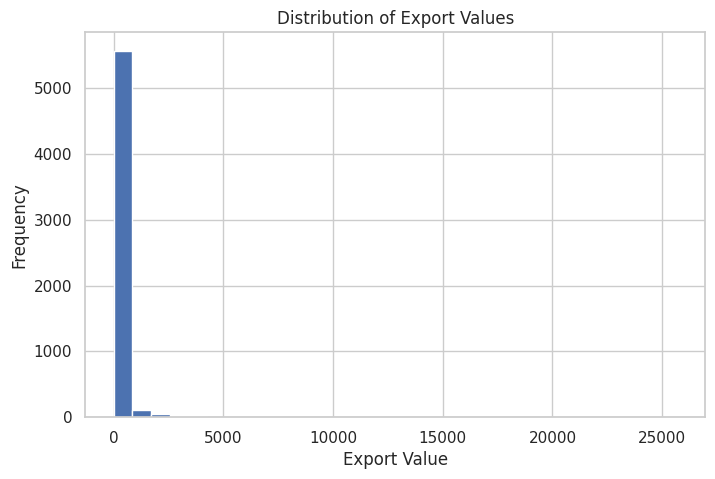

In [60]:
# ==========================================================
# 4.4 EXPORT VALUE DISTRIBUTION
# ==========================================================
#
# Objective:
# Understand the distribution of export values.
#
# This helps identify:
# • Skewness
# • Outliers
# • Extreme exporting markets
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(master["Export_Current"].dropna(), bins=30)

plt.title("Distribution of Export Values")

plt.xlabel("Export Value")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

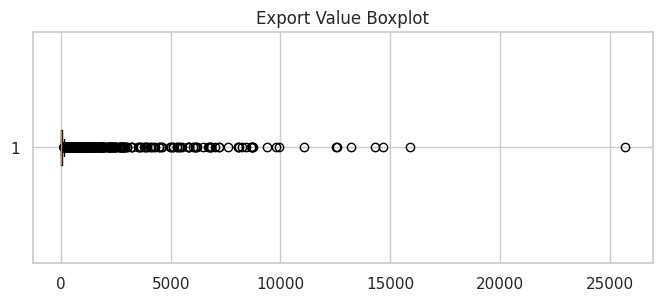

In [61]:
# ==============================================================================
# BOXPLOT
# ==============================================================================

plt.figure(figsize=(8,3))

plt.boxplot(
    master["Export_Current"].dropna(),
    vert=False
)

plt.title("Export Value Boxplot")

plt.show()

In [62]:
# ==========================================================
# 4.5 TOP EXPORT DESTINATIONS
# ==========================================================
#
# Objective:
# Identify countries importing the largest value of
# Indian exports across all selected commodities.
# ==========================================================

top_countries = (

    master.groupby("Country")["Export_Current"]

    .sum()

    .sort_values(ascending=False)

    .head(20)

)

display(top_countries)

,Export_Current
Country,
U S A,226419.90
U Arab Emts,99841.05
Netherland,69827.78
Singapore,46740.49
Hong Kong,44092.31
U K,28773.40
Australia,27872.03
China P Rp,23648.21
South Africa,22704.61


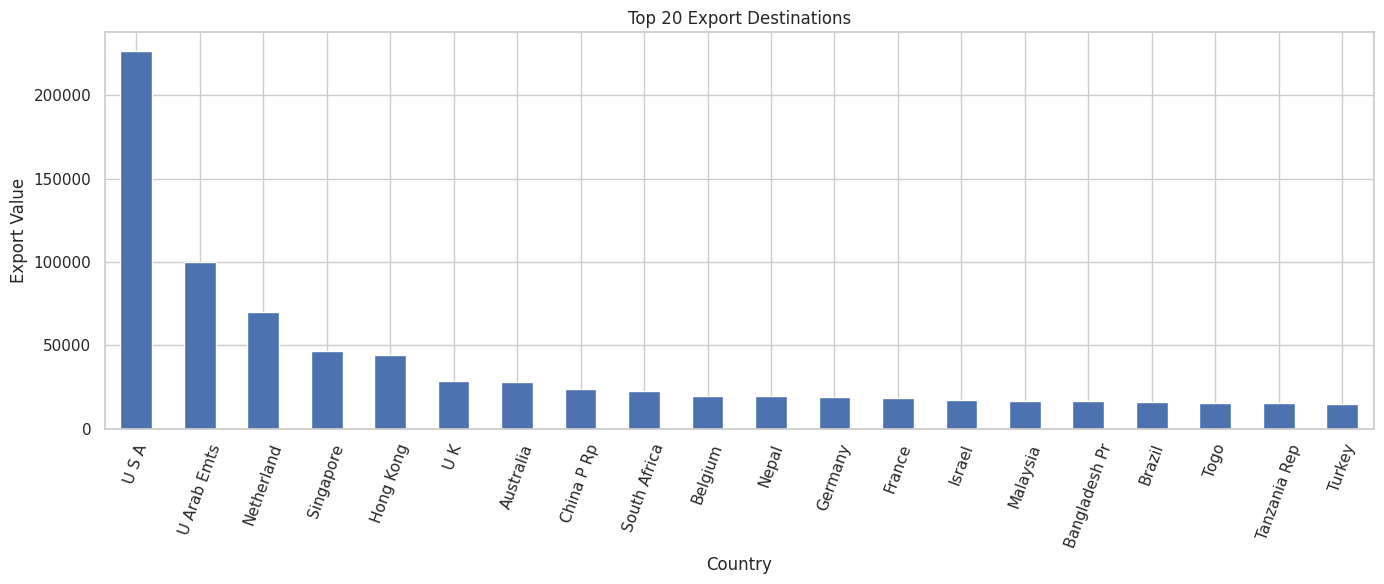

In [63]:
# ==========================================================
# VISUALIZATION:
# TOP 20 EXPORT DESTINATIONS
# ==========================================================

plt.figure(figsize=(14,6))

top_countries.plot(kind="bar")

plt.title("Top 20 Export Destinations")

plt.xlabel("Country")

plt.ylabel("Export Value")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

In [64]:
# ==========================================================
# 4.6 COMMODITY-WISE EXPORT ANALYSIS
# ==========================================================
#
# Objective:
# Compare export values across the selected HS commodities.
# ==========================================================

commodity_export = (

    master.groupby("Commodity")["Export_Current"]

    .sum()

    .sort_values(ascending=False)

)

display(commodity_export)

,Export_Current
Commodity,
27,408239.25
85,195439.67
84,172002.63
71,164741.88
30,130399.15


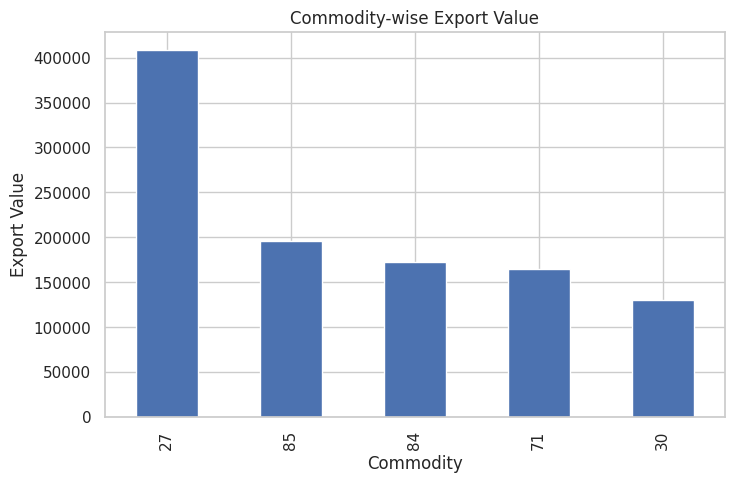

In [65]:
plt.figure(figsize=(8,5))

commodity_export.plot(kind="bar")

plt.title("Commodity-wise Export Value")

plt.xlabel("Commodity")

plt.ylabel("Export Value")

plt.grid(True)

plt.show()

In [66]:
# ==========================================================
# 4.7 EXPORT TREND ANALYSIS
# ==========================================================
#
# Objective:
# Examine how exports have changed over time.
#
# Helps answer Research Question 1.
# ==========================================================

yearly_export = (

    master.groupby("Year")["Export_Current"]

    .sum()

)

display(yearly_export)

,Export_Current
Year,
2021,105623.29
2022,173823.79
2023,215301.71
2024,207030.96
2025,197492.25
2026,171550.58


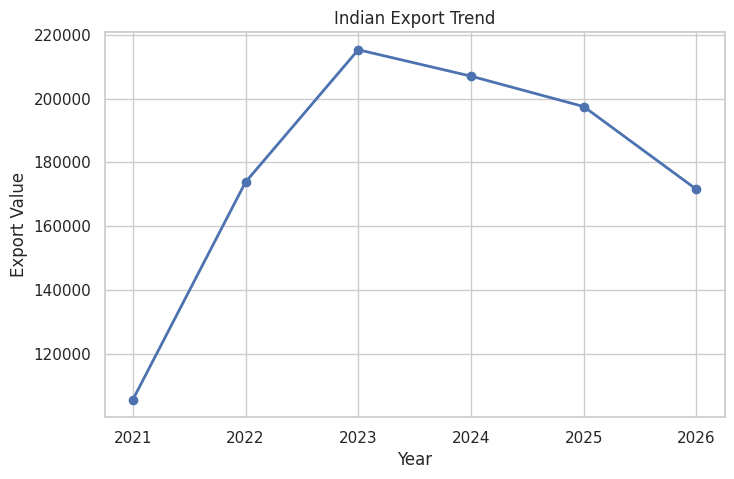

In [67]:
plt.figure(figsize=(8,5))

plt.plot(

    yearly_export.index,

    yearly_export.values,

    marker="o",

    linewidth=2

)

plt.title("Indian Export Trend")

plt.xlabel("Year")

plt.ylabel("Export Value")

plt.grid(True)

plt.show()

In [68]:
# ==============================================================================
# TOP IMPORTING COUNTRIES FOR EACH COMMODITY
# ==============================================================================

commodity_country = (

    master.groupby(["Commodity","Country"])

    ["Export_Current"]

    .sum()

    .reset_index()

)

display(commodity_country.head())

,Commodity,Country,Export_Current
0,27,Afghanistan,2.61
1,27,Albania,1347.88
2,27,Algeria,10.00
3,27,Angola,442.22
4,27,Antartica,0.30


In [69]:
# ==========================================================
# 4.8 CORRELATION ANALYSIS
# ==========================================================
#
# Objective:
# Identify relationships between exports and
# macroeconomic indicators.
#
# Variables considered:
# • GDP
# • GDP Growth
# • Population
# • Inflation
# • Trade
# ==========================================================

corr = master[[
    "Export_Current",
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]].corr()

display(corr)

,Export_Current,GDP,GDP_Growth,GDP_Per_Capita,Population,Inflation,Exports_GDP,Imports_GDP,Trade_GDP
Export_Current,1.000000,0.263329,-0.039419,0.097846,0.198948,-0.041686,0.088869,0.041568,0.069577
GDP,0.263329,1.000000,-0.103103,0.216603,0.499748,-0.063056,-0.063503,-0.170265,-0.115598
GDP_Growth,-0.039419,-0.103103,1.000000,0.010233,-0.074215,-0.135838,0.123424,0.098318,0.115716
GDP_Per_Capita,0.097846,0.216603,0.010233,1.000000,-0.150847,-0.127295,0.526326,0.337071,0.454751
Population,0.198948,0.499748,-0.074215,-0.150847,1.000000,0.039021,-0.280226,-0.349980,-0.322207
Inflation,-0.041686,-0.063056,-0.135838,-0.127295,0.039021,1.000000,-0.158126,-0.123745,-0.146908
Exports_GDP,0.088869,-0.063503,0.123424,0.526326,-0.280226,-0.158126,1.000000,0.873196,0.973495
Imports_GDP,0.041568,-0.170265,0.098318,0.337071,-0.349980,-0.123745,0.873196,1.000000,0.961517
Trade_GDP,0.069577,-0.115598,0.115716,0.454751,-0.322207,-0.146908,0.973495,0.961517,1.000000


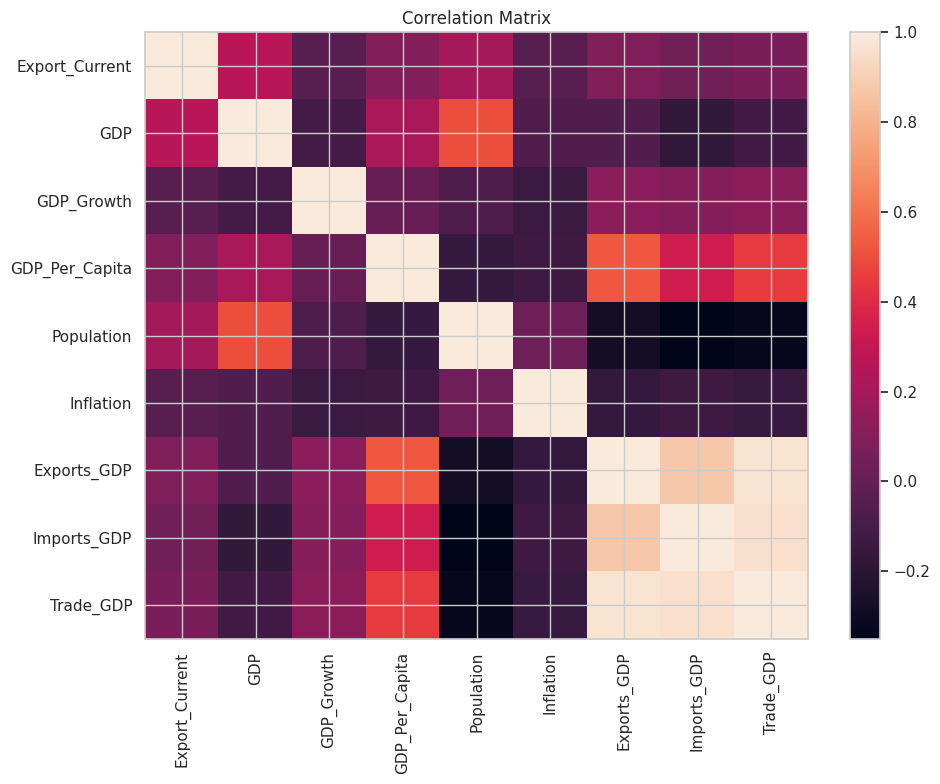

In [70]:
plt.figure(figsize=(10,8))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [71]:
##need to apply this in cleansing
import numpy as np

# Replace infinity values with NaN
master["Export_Growth_Rate"] = master["Export_Growth_Rate"].replace(
    [np.inf, -np.inf],
    np.nan
)

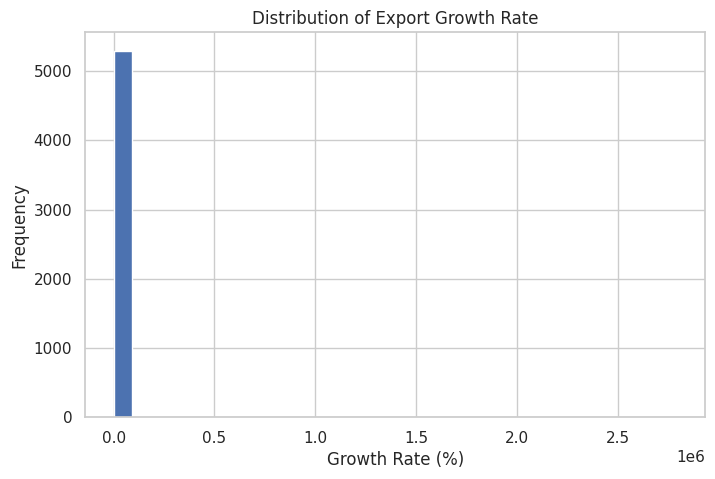

In [72]:
# ==========================================================
# 4.9 EXPORT GROWTH ANALYSIS
# ==========================================================
#
# Objective:
# Understand the distribution of export growth rates.
# ==========================================================

master["Export_Growth_Rate"].describe()
plt.figure(figsize=(8,5))

plt.hist(
    master["Export_Growth_Rate"].dropna(),
    bins=30
)

plt.title("Distribution of Export Growth Rate")

plt.xlabel("Growth Rate (%)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [73]:
# ==============================================================================
# RESEARCH QUESTION 1
#
# Which countries exhibit the highest demand for selected Indian export
# commodities?
#
# ==============================================================================

market_share = (

    master.groupby("Country")

    ["Export_Current"]

    .sum()

    .sort_values(ascending=False)

)

market_share = (

    market_share /

    market_share.sum()

)*100

market_share.head(20)

,Export_Current
Country,
U S A,21.144483
U Arab Emts,9.323771
Netherland,6.520948
Singapore,4.364914
Hong Kong,4.117611
U K,2.687037
Australia,2.602862
China P Rp,2.208415
South Africa,2.120296


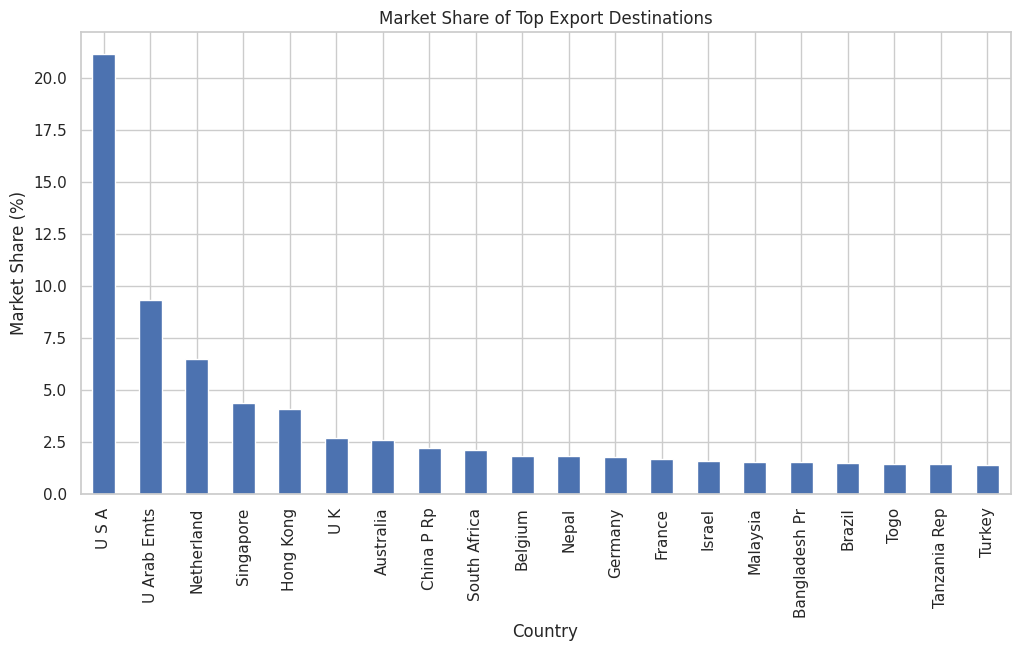

In [74]:
##Market Share Plot
plt.figure(figsize=(12,6))

market_share.head(20).plot(kind="bar")

plt.title("Market Share of Top Export Destinations")

plt.ylabel("Market Share (%)")

plt.show()

In [75]:
##Commodity-Year Trend
commodity_year = (

    master.groupby(["Year","Commodity"])

    ["Export_Current"]

    .sum()

    .reset_index()

)

display(commodity_year.head())

,Year,Commodity,Export_Current
0,2021,27,26907.73
1,2021,30,19383.97
2,2021,71,26163.85
3,2021,84,18953.97
4,2021,85,14213.77


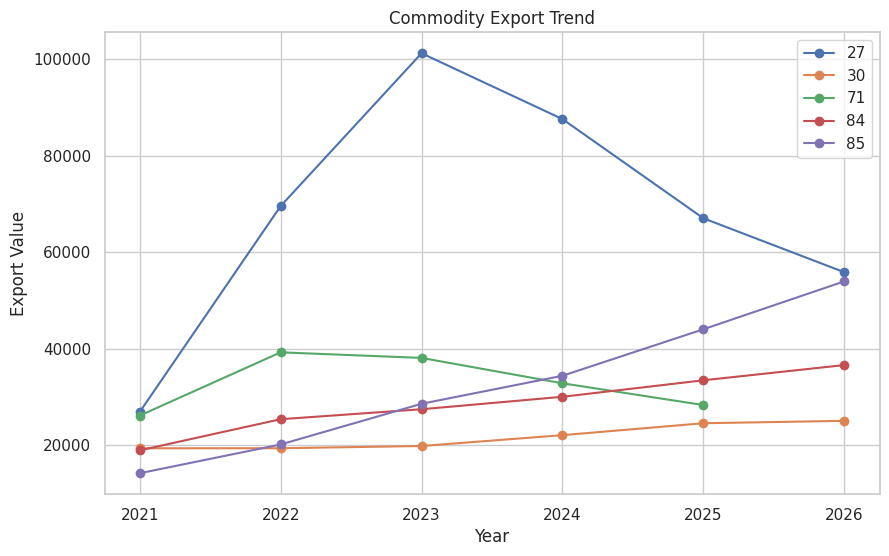

In [76]:
# Trend by Commodity
plt.figure(figsize=(10,6))

for commodity in commodity_year["Commodity"].unique():

    subset = commodity_year[
        commodity_year["Commodity"]==commodity
    ]

    plt.plot(

        subset["Year"],

        subset["Export_Current"],

        marker="o",

        label=commodity

    )

plt.legend()

plt.title("Commodity Export Trend")

plt.xlabel("Year")

plt.ylabel("Export Value")

plt.grid(True)

plt.show()

RESEARCH QUESTION 2

,Export_Current,GDP,GDP_Growth,GDP_Per_Capita,Population,Inflation,Exports_GDP,Imports_GDP,Trade_GDP
Export_Current,1.000000,0.263329,-0.039419,0.097846,0.198948,-0.041686,0.088869,0.041568,0.069577
GDP,0.263329,1.000000,-0.103103,0.216603,0.499748,-0.063056,-0.063503,-0.170265,-0.115598
GDP_Growth,-0.039419,-0.103103,1.000000,0.010233,-0.074215,-0.135838,0.123424,0.098318,0.115716
GDP_Per_Capita,0.097846,0.216603,0.010233,1.000000,-0.150847,-0.127295,0.526326,0.337071,0.454751
Population,0.198948,0.499748,-0.074215,-0.150847,1.000000,0.039021,-0.280226,-0.349980,-0.322207
Inflation,-0.041686,-0.063056,-0.135838,-0.127295,0.039021,1.000000,-0.158126,-0.123745,-0.146908
Exports_GDP,0.088869,-0.063503,0.123424,0.526326,-0.280226,-0.158126,1.000000,0.873196,0.973495
Imports_GDP,0.041568,-0.170265,0.098318,0.337071,-0.349980,-0.123745,0.873196,1.000000,0.961517
Trade_GDP,0.069577,-0.115598,0.115716,0.454751,-0.322207,-0.146908,0.973495,0.961517,1.000000


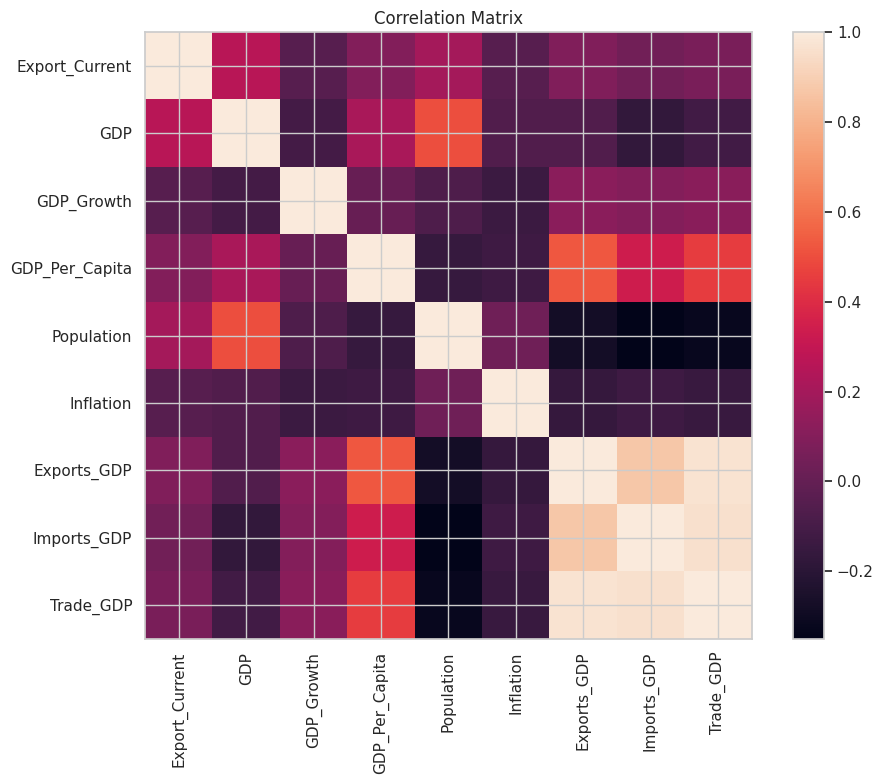

In [77]:
# ==============================================================================
# RESEARCH QUESTION 2
#
# Which macroeconomic indicators influence export demand?
#
# ==============================================================================

corr = master[[
    "Export_Current",
    "GDP",
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population",
    "Inflation",
    "Exports_GDP",
    "Imports_GDP",
    "Trade_GDP"
]].corr()

display(corr)
plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

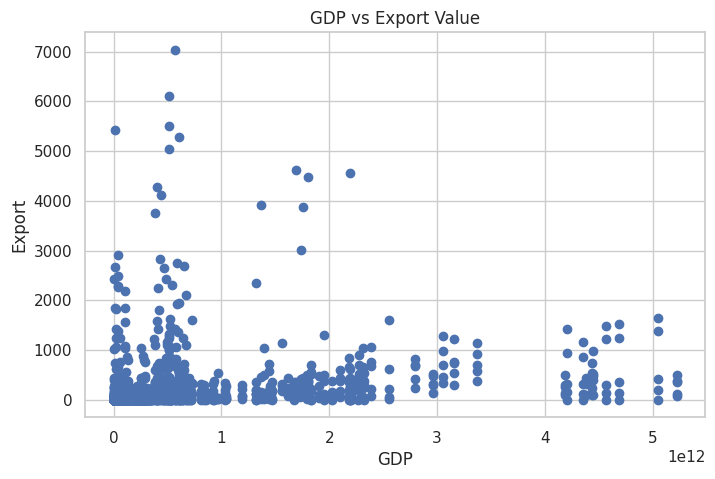

In [78]:
##GDP vs Export
plt.figure(figsize=(8,5))

plt.scatter(

    master["GDP"],

    master["Export_Current"]

)

plt.title("GDP vs Export Value")

plt.xlabel("GDP")

plt.ylabel("Export")

plt.show()

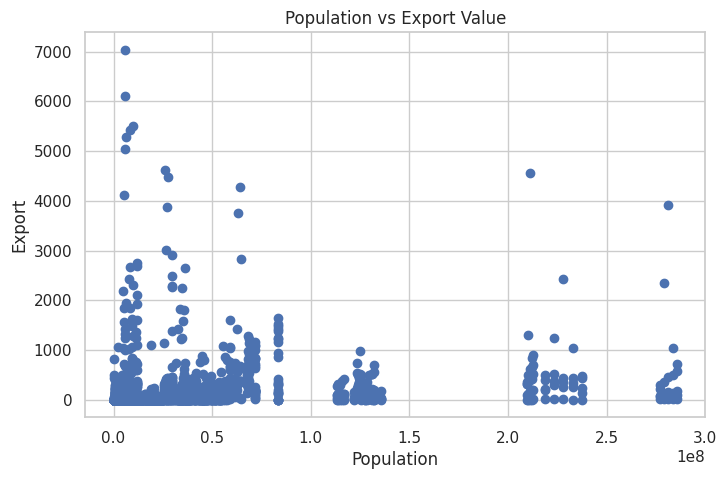

In [79]:
## Population vs Export
plt.figure(figsize=(8,5))

plt.scatter(

    master["Population"],

    master["Export_Current"]

)

plt.title("Population vs Export Value")

plt.xlabel("Population")

plt.ylabel("Export")

plt.show()